In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
EKSTRAKSI WAVEFORM KE JSON (1C dan 3C) + FILTER SNR
- 1C: hanya komponen Z (semua event yang memiliki Z)
- 3C: hanya event dengan Z, N, E lengkap + Filter SNR minimal
- Preprocessing: detrend, resample 100 Hz, normalisasi max 9 detik setelah P
- STA/LTA untuk P-wave picking (Fallback diperbaiki)
- Parallel processing dengan resume
"""

import os
import sys
import json
import numpy as np
from pathlib import Path
from obspy import read
from obspy.signal.trigger import recursive_sta_lta
from tqdm import tqdm
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed

# =============================================
# 1. KONFIGURASI
# =============================================

WAVEFORM_DIR = '/Volumes/Extreme SSD/unduhan_waveform_geofon_juli'
OUTPUT_JSON_1C = '/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_1c_sesi_5.json'
OUTPUT_JSON_3C = '/Volumes/Extreme SSD/json_juli_1c_3c/extracted_data_3c_sesi_5.json'
LOG_FILE = "extract_waveforms_both.log"

# Parameter MCU-Quake
SAMPLE_RATE = 100.0
SIG_DURATION = 7.0
NOISE_DURATION = 7.0
NORM_WINDOW = 9.0

# Parameter STA/LTA
STA_WIN = 0.5
LTA_WIN = 15.0
TRIGGER_THRESHOLD = 2.5

# Konfigurasi Filter SNR (dB) untuk memastikan kemurnian dataset 3C
MIN_SNR_DB = 2.0  

# Parallel
MAX_WORKERS = 8

# Ukuran file minimum (skip file corrupt/kecil)
MIN_FILE_SIZE_BYTES = 1024  # 1 KB

# =============================================
# 2. SETUP LOGGING
# =============================================

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

# =============================================
# 3. FUNGSI PREPROCESSING
# =============================================

def pick_p_arrival(trace):
    """
    Deteksi P-wave arrival menggunakan STA/LTA.
    Fallback: cari puncak maksimum dalam jendela 0-15 detik SETELAH origin.
    """
    try:
        sr = trace.stats.sampling_rate
        sta_n = int(STA_WIN * sr)
        lta_n = int(LTA_WIN * sr)
        
        if len(trace.data) < lta_n + sta_n:
            return trace.stats.starttime + 5.0
        
        cft = recursive_sta_lta(trace.data, sta_n, lta_n)
        trigger_indices = np.where(cft > TRIGGER_THRESHOLD)[0]
        
        if len(trigger_indices) > 0:
            pick_idx = trigger_indices[0]
            if 0 < pick_idx < len(trace.data):
                return trace.stats.starttime + pick_idx / sr
        
        # Fallback pencarian puncak setelah perkiraan origin (30 detik awal)
        origin_sample = int(30 * sr)  
        start_idx = max(0, origin_sample)
        end_idx = min(len(trace.data), origin_sample + int(15 * sr))
        
        if end_idx > start_idx:
            max_idx = np.argmax(np.abs(trace.data[start_idx:end_idx])) + start_idx
            if max_idx > 0:
                return trace.stats.starttime + max_idx / sr
        
    except Exception as e:
        logger.debug(f"Error in pick_p_arrival: {e}")
    
    return trace.stats.starttime + 35.0  

def extract_component_windows(trace, p_time):
    """Ekstraksi sinyal dan noise untuk satu trace komponen."""
    try:
        tr_signal = trace.copy().trim(p_time, p_time + SIG_DURATION)
        tr_noise = trace.copy().trim(p_time - NOISE_DURATION, p_time)
        
        tr_signal.detrend('simple')
        tr_noise.detrend('simple')
        
        if tr_signal.stats.sampling_rate != SAMPLE_RATE:
            tr_signal.resample(SAMPLE_RATE)
        if tr_noise.stats.sampling_rate != SAMPLE_RATE:
            tr_noise.resample(SAMPLE_RATE)
        
        tr_norm = trace.copy().trim(p_time, p_time + NORM_WINDOW)
        if len(tr_norm.data) > 0:
            max_val = np.max(np.abs(tr_norm.data))
        else:
            max_val = np.max(np.abs(tr_signal.data))
        
        if np.isnan(max_val) or max_val < 1e-6:
            max_val = 1.0
        
        signal_data = tr_signal.data / max_val
        noise_data = tr_noise.data / max_val
        
        target_len = int(SAMPLE_RATE * SIG_DURATION)
        def fix_length(data):
            if len(data) > target_len:
                return data[:target_len]
            elif len(data) < target_len:
                return np.pad(data, (0, target_len - len(data)), 'constant')
            return data
        
        return fix_length(signal_data).tolist(), fix_length(noise_data).tolist()
    except Exception as e:
        return None, None

def process_file(file_path):
    """
    Proses satu file .mseed.
    Return dict dengan komponen yang tersedia (Z, N, E) atau None jika gagal.
    """
    try:
        st = read(str(file_path))
        if len(st) == 0:
            return None
        
        trace_z = None
        trace_n = None
        trace_e = None
        
        for tr in st:
            ch = tr.stats.channel
            if ch.endswith('Z'):
                trace_z = tr
            elif ch.endswith('N'):
                trace_n = tr
            elif ch.endswith('E'):
                trace_e = tr
        
        if trace_z is None:
            return None
        
        p_time = pick_p_arrival(trace_z)
        
        z_signal, z_noise = extract_component_windows(trace_z, p_time)
        if z_signal is None:
            return None
        
        # --- HITUNG SNR PADA KOMPONEN Z (Validasi Kualitas) ---
        var_sig = np.var(np.array(z_signal))
        var_noise = np.var(np.array(z_noise))
        if var_noise == 0:
            snr_db = 100.0
        else:
            snr_db = 10 * np.log10(var_sig / var_noise)
        
        if snr_db < MIN_SNR_DB:
            return None  # Drop jika SNR terlalu rendah
        # -----------------------------------------------------

        result = {
            'event_id': file_path.stem,
            'network': trace_z.stats.network,
            'station': trace_z.stats.station,
            'p_arrival': str(p_time),
            'file': file_path.name,
            'snr_db': round(snr_db, 2),
            'has_z': True,
            'has_n': False,
            'has_e': False,
            'Z': z_signal,
            'Z_noise': z_noise,
        }
        
        if trace_n is not None:
            n_signal, n_noise = extract_component_windows(trace_n, p_time)
            if n_signal is not None:
                result['has_n'] = True
                result['N'] = n_signal
                result['N_noise'] = n_noise
        
        if trace_e is not None:
            e_signal, e_noise = extract_component_windows(trace_e, p_time)
            if e_signal is not None:
                result['has_e'] = True
                result['E'] = e_signal
                result['E_noise'] = e_noise
        
        return result
    except Exception as e:
        logger.debug(f"Error processing {file_path.name}: {e}")
        return None

# =============================================
# 4. MAIN SCRIPT
# =============================================

def main():
    logger.info("="*70)
    logger.info("🚀 EKSTRAKSI WAVEFORM KE JSON (1C dan 3C) + SNR FILTER")
    logger.info("="*70)
    
    os.makedirs(os.path.dirname(OUTPUT_JSON_1C), exist_ok=True)
    os.makedirs(os.path.dirname(OUTPUT_JSON_3C), exist_ok=True)
    
    wave_dir = Path(WAVEFORM_DIR)
    all_files = list(wave_dir.glob("*.mseed"))
    all_files = [f for f in all_files if f.stat().st_size >= MIN_FILE_SIZE_BYTES]
    logger.info(f"📁 Ditemukan {len(all_files)} file .mseed (≥ {MIN_FILE_SIZE_BYTES//1024} KB)")

    data_1c = {}
    data_3c = {}
    
    if os.path.exists(OUTPUT_JSON_1C):
        with open(OUTPUT_JSON_1C, 'r') as f:
            data_1c = json.load(f)
        logger.info(f"📂 Load JSON 1C existing: {len(data_1c)} entries")
    if os.path.exists(OUTPUT_JSON_3C):
        with open(OUTPUT_JSON_3C, 'r') as f:
            data_3c = json.load(f)
        logger.info(f"📂 Load JSON 3C existing: {len(data_3c)} entries")
    
    files_to_process = [f for f in all_files if f.stem not in data_1c]
    logger.info(f"📦 File baru yang akan diproses: {len(files_to_process)}")
    
    if len(files_to_process) == 0:
        logger.info("✅ Semua file sudah diproses!")
        logger.info(f"📁 Total 1C: {len(data_1c)}")
        logger.info(f"📁 Total 3C: {len(data_3c)}")
        return
    
    success_1c = 0
    success_3c = 0
    failed = 0
    
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(process_file, f): f for f in files_to_process}
        with tqdm(total=len(futures), desc="Ekstraksi", unit="file") as pbar:
            for future in as_completed(futures):
                result = future.result()
                
                if result:
                    key = result['event_id']
                    
                    # Simpan ke 1C
                    data_1c[key] = {
                        'type': 'se',
                        'Z': result['Z'],
                        'Z_noise': result['Z_noise'],
                        'metadata': {
                            'network': result['network'],
                            'station': result['station'],
                            'p_arrival': result['p_arrival'],
                            'file': result['file'],
                            'snr_db': result['snr_db']
                        }
                    }
                    success_1c += 1
                    
                    # Simpan ke 3C hanya jika N, E, dan Z lengkap
                    if result['has_n'] and result['has_e']:
                        data_3c[key] = {
                            'type': 'se',
                            'Z': result['Z'],
                            'N': result['N'],
                            'E': result['E'],
                            'Z_noise': result['Z_noise'],
                            'N_noise': result['N_noise'],
                            'E_noise': result['E_noise'],
                            'metadata': {
                                'network': result['network'],
                                'station': result['station'],
                                'p_arrival': result['p_arrival'],
                                'file': result['file'],
                                'snr_db': result['snr_db']
                            }
                        }
                        success_3c += 1
                else:
                    failed += 1
                
                pbar.update(1)
                
                # Simpan berkala setiap 100 iterasi (Atomic Save aman)
                if (success_1c + failed) % 100 == 0:
                    with open(OUTPUT_JSON_1C, 'w') as f:
                        json.dump(data_1c, f, indent=2)
                    with open(OUTPUT_JSON_3C, 'w') as f:
                        json.dump(data_3c, f, indent=2)
    
    # Simpan final
    with open(OUTPUT_JSON_1C, 'w') as f:
        json.dump(data_1c, f, indent=2)
    with open(OUTPUT_JSON_3C, 'w') as f:
        json.dump(data_3c, f, indent=2)
    
    logger.info("="*70)
    logger.info(f"✨ SELESAI!")
    logger.info(f"✅ 1C Valid: {len(data_1c)} entries")
    logger.info(f"✅ 3C Valid (Lengkap Z,N,E): {len(data_3c)} entries")
    logger.info(f"❌ Gagal / Drop SNR < {MIN_SNR_DB}dB: {failed}")
    logger.info(f"📂 Output 1C: {OUTPUT_JSON_1C}")
    logger.info(f"📂 Output 3C: {OUTPUT_JSON_3C}")
    logger.info("="*70)

if __name__ == "__main__":
    main()

2026-07-28 05:48:04,051 - INFO - ============================================================
2026-07-28 05:48:04,052 - INFO - 🚀 EKSTRAKSI WAVEFORM KE JSON (MCU-QUAKE 1C) + SNR FILTER
2026-07-28 05:48:04,053 - INFO - ============================================================
2026-07-28 05:48:04,362 - INFO - 📁 Ditemukan 40430 file .mseed
2026-07-28 05:48:04,386 - INFO - 📂 Load JSON existing: 170 entries


Memproses:   0%|          | 2/40430 [00:00<1:19:20,  8.49it/s]

2026-07-28 05:48:04,691 - WARNING - Terdeteksi nilai NaN/Inf pada waveform. Data didrop.


/opt/homebrew/Caskroom/miniforge/base/envs/tf-metal/lib/python3.11/site-packages/obspy/signal/detrend.py:31: RuntimeWarning: invalid value encountered in divide
  data -= x1 + np.arange(ndat) * (x2 - x1) / float(ndat - 1)
Memproses:   1%|          | 278/40430 [00:01<04:13, 158.64it/s]/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_2997/1947458494.py:134: RuntimeWarning: divide by zero encountered in log10
  snr_db = 10 * np.log10(var_sig / var_noise)
Memproses:   4%|▍         | 1561/40430 [00:09<03:50, 168.82it/s]

2026-07-28 05:48:14,053 - WARNING - Terdeteksi nilai NaN/Inf pada waveform. Data didrop.


...

2026-07-28 05:57:53,712 - WARNING - Terdeteksi nilai NaN/Inf pada waveform. Data didrop.


Memproses:  87%|████████▋ | 35104/40430 [12:50<04:26, 20.01it/s]

2026-07-28 06:00:54,942 - WARNING - Terdeteksi nilai NaN/Inf pada waveform. Data didrop.


Memproses: 100%|██████████| 40430/40430 [16:45<00:00, 40.23it/s]


2026-07-28 06:04:54,063 - INFO - ============================================================
2026-07-28 06:04:54,064 - INFO - ✨ SELESAI! Berhasil: 6916, Gagal (termasuk drop SNR < 2.0dB): 33344, Skipped: 170
2026-07-28 06:04:54,064 - INFO - 📁 Total data valid di JSON: 7086
2026-07-28 06:04:54,064 - INFO - 📂 Output: /Volumes/Extreme SSD/json_indonesia_juli_sesi_5/mcu_quake_1c_indonesia_snr.json
2026-07-28 06:04:54,065 - INFO - ============================================================


In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
EKSTRAKSI WAVEFORM KE JSON (1C dan 3C) + ADVANCED DATA CLEANING
- Bandpass Filtering (1.0 - 20.0 Hz)
- Validasi Kontinuitas Energi P-Arrival
- Filter SNR Ketat (Min 3.0 dB)
- Proteksi NaN, Clipping, & Zero Variance
"""

import os
import sys
import json
import numpy as np
from pathlib import Path
from obspy import read
from obspy.signal.trigger import recursive_sta_lta
from tqdm import tqdm
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed

# =============================================
# 1. KONFIGURASI
# =============================================

WAVEFORM_DIR = '/Volumes/Extreme SSD/unduhan_waveform_geofon_juli'
OUTPUT_JSON_1C = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_5/extracted_data_1c_sesi_clean.json'
OUTPUT_JSON_3C = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_5/extracted_data_3c_sesi_clean.json'
LOG_FILE = "extract_waveforms_clean.log"

# Parameter MCU-Quake & Filtering
SAMPLE_RATE = 100.0
SIG_DURATION = 7.0
NOISE_DURATION = 7.0
NORM_WINDOW = 9.0
FREQ_MIN = 1.0   # Batas bawah Bandpass (Hz) - Menolak mikroseismik laut
FREQ_MAX = 20.0  # Batas atas Bandpass (Hz) - Menolak derau instrumen

# Parameter STA/LTA
STA_WIN = 0.5
LTA_WIN = 15.0
TRIGGER_THRESHOLD = 2.5

# Konfigurasi Filter SNR (dB) yang lebih ketat untuk domain Indonesia
MIN_SNR_DB = 3.0  

# Parallel
MAX_WORKERS = 8
MIN_FILE_SIZE_BYTES = 1024  # 1 KB

# =============================================
# 2. SETUP LOGGING
# =============================================

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

# =============================================
# 3. FUNGSI PREPROCESSING & CLEANING
# =============================================

def pick_p_arrival(trace):
    """
    Deteksi P-wave arrival menggunakan STA/LTA dengan validasi energi berkelanjutan.
    """
    try:
        sr = trace.stats.sampling_rate
        sta_n = int(STA_WIN * sr)
        lta_n = int(LTA_WIN * sr)
        
        if len(trace.data) < lta_n + sta_n:
            return None
        
        cft = recursive_sta_lta(trace.data, sta_n, lta_n)
        trigger_indices = np.where(cft > TRIGGER_THRESHOLD)[0]
        
        pick_idx = None
        if len(trigger_indices) > 0:
            pick_idx = trigger_indices[0]
        else:
            # Fallback pencarian puncak setelah origin (30 detik awal)
            origin_sample = int(30 * sr)  
            start_idx = max(0, origin_sample)
            end_idx = min(len(trace.data), origin_sample + int(15 * sr))
            if end_idx > start_idx:
                max_idx = np.argmax(np.abs(trace.data[start_idx:end_idx])) + start_idx
                if max_idx > 0:
                    pick_idx = max_idx
        
        if pick_idx is not None and 0 < pick_idx < len(trace.data):
            # Validasi Kontinuitas Energi: pastikan energi setelah pick_idx benar-benar naik
            window_check = trace.data[pick_idx:pick_idx + int(0.5 * sr)]
            if len(window_check) > 0 and np.max(np.abs(window_check)) > 0:
                return trace.stats.starttime + pick_idx / sr
                
    except Exception as e:
        logger.debug(f"Error in pick_p_arrival: {e}")
    
    return None

def extract_and_clean_window(trace, p_time):
    """Ekstraksi, Bandpass Filter (Anti-Edge Artifact), normalisasi, dan validasi."""
    try:
        PRE_EVENT_BUFFER = 1.0
        FILTER_PADDING = 10.0  # Buffer 10 detik tambahan untuk meredam artefak filter
        
        # 1. AMBIL JENDELA LEBAR (WIDE WINDOW)
        # Ambil jendela yang jauh lebih panjang dari yang dibutuhkan agar efek kejut 
        # dari bandpass filter tidak merusak data sinyal/noise utama kita.
        start_wide = p_time - NOISE_DURATION - PRE_EVENT_BUFFER - FILTER_PADDING
        end_wide = p_time + SIG_DURATION - PRE_EVENT_BUFFER + FILTER_PADDING
        
        tr_wide = trace.copy().trim(start_wide, end_wide)
        
        if len(tr_wide.data) == 0:
            return None, None
            
        # 2. FILTERING PADA JENDELA LEBAR
        tr_wide.detrend('simple')
        tr_wide.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
        
        # 3. RESAMPLING
        if tr_wide.stats.sampling_rate != SAMPLE_RATE:
            tr_wide.resample(SAMPLE_RATE)
            
        # 4. PEMOTONGAN PRESISI (EXACT SLICING)
        # Sekarang, potong jendela sinyal dan noise dari data yang SUDAH DIFILTER dan BERSIH
        
        # Sinyal: Mundur 1 detik agar P-Pick berada di indeks ~100
        tr_signal = tr_wide.copy().trim(p_time - PRE_EVENT_BUFFER, p_time + SIG_DURATION - PRE_EVENT_BUFFER)
        
        # Noise: Mundur agar tepat bersambung namun tidak tumpang tindih dengan pre-event sinyal
        tr_noise = tr_wide.copy().trim(p_time - NOISE_DURATION - PRE_EVENT_BUFFER, p_time - PRE_EVENT_BUFFER)
        
        # Jendela Normalisasi (9 detik)
        tr_norm = tr_wide.copy().trim(p_time - PRE_EVENT_BUFFER, p_time - PRE_EVENT_BUFFER + NORM_WINDOW)
        
        max_val = np.max(np.abs(tr_norm.data)) if len(tr_norm.data) > 0 else np.max(np.abs(tr_signal.data))
        
        # Proteksi nilai ekstrem, zero variance, atau NaN
        if np.isnan(max_val) or max_val < 1e-6:
            return None, None
            
        signal_data = tr_signal.data / max_val
        noise_data = tr_noise.data / max_val
        
        # Validasi akhir: pastikan tidak ada NaN atau Inf yang lolos
        if np.isnan(signal_data).any() or np.isnan(noise_data).any() or np.isinf(signal_data).any():
            return None, None
            
        # 5. PADDING / TRIMMING AKHIR (Memastikan array mutlak 700 sampel)
        target_len = int(SAMPLE_RATE * SIG_DURATION)
        def fix_length(data):
            if len(data) > target_len:
                return data[:target_len]
            elif len(data) < target_len:
                return np.pad(data, (0, target_len - len(data)), 'constant')
            return data
        
        return fix_length(signal_data).tolist(), fix_length(noise_data).tolist()
        
    except Exception as e:
        return None, None

def process_file(file_path):
    """Proses satu file .mseed dengan kontrol kualitas menyeluruh."""
    try:
        st = read(str(file_path))
        if len(st) == 0:
            return None
        
        trace_z, trace_n, trace_e = None, None, None
        
        for tr in st:
            ch = tr.stats.channel
            if ch.endswith('Z'): trace_z = tr
            elif ch.endswith('N'): trace_n = tr
            elif ch.endswith('E'): trace_e = tr
        
        if trace_z is None:
            return None
        
        # P-Wave Picking
        p_time = pick_p_arrival(trace_z)
        if p_time is None:
            return None
            
        # Ekstraksi Komponen Z Utama
        z_signal, z_noise = extract_and_clean_window(trace_z, p_time)
        if z_signal is None:
            return None
        
        # Hitung SNR pada Komponen Z yang sudah difilter
        var_sig = np.var(np.array(z_signal))
        var_noise = np.var(np.array(z_noise))
        if var_noise == 0:
            return None
            
        snr_db = 10 * np.log10(var_sig / var_noise)
        if snr_db < MIN_SNR_DB:
            return None  # Drop jika kualitas SNR di bawah batas aman
            
        result = {
            'event_id': file_path.stem,
            'network': trace_z.stats.network,
            'station': trace_z.stats.station,
            'p_arrival': str(p_time),
            'file': file_path.name,
            'snr_db': round(snr_db, 2),
            'has_z': True, 'has_n': False, 'has_e': False,
            'Z': z_signal, 'Z_noise': z_noise,
        }
        
        # Ekstraksi N jika ada dan valid
        if trace_n is not None:
            n_signal, n_noise = extract_and_clean_window(trace_n, p_time)
            if n_signal is not None:
                result['has_n'] = True
                result['N'] = n_signal
                result['N_noise'] = n_noise
        
        # Ekstraksi E jika ada dan valid
        if trace_e is not None:
            e_signal, e_noise = extract_and_clean_window(trace_e, p_time)
            if e_signal is not None:
                result['has_e'] = True
                result['E'] = e_signal
                result['E_noise'] = e_noise
        
        return result
    except Exception as e:
        logger.debug(f"Error processing {file_path.name}: {e}")
        return None

# =============================================
# 4. MAIN SCRIPT
# =============================================

def main():
    logger.info("="*70)
    logger.info("🚀 EKSTRAKSI & CLEANING LANJUTAN WAVEFORM INDONESIA (1C & 3C)")
    logger.info("="*70)
    
    os.makedirs(os.path.dirname(OUTPUT_JSON_1C), exist_ok=True)
    os.makedirs(os.path.dirname(OUTPUT_JSON_3C), exist_ok=True)
    
    wave_dir = Path(WAVEFORM_DIR)
    all_files = list(wave_dir.glob("*.mseed"))
    all_files = [f for f in all_files if f.stat().st_size >= MIN_FILE_SIZE_BYTES]
    logger.info(f"📁 Ditemukan {len(all_files)} file .mseed di direktori.")

    data_1c, data_3c = {}, {}
    
    if os.path.exists(OUTPUT_JSON_1C):
        with open(OUTPUT_JSON_1C, 'r') as f: data_1c = json.load(f)
    if os.path.exists(OUTPUT_JSON_3C):
        with open(OUTPUT_JSON_3C, 'r') as f: data_3c = json.load(f)
        
    files_to_process = [f for f in all_files if f.stem not in data_1c]
    logger.info(f"📦 File baru yang akan diproses & dibersihkan: {len(files_to_process)}")
    
    if len(files_to_process) == 0:
        logger.info("✅ Seluruh file telah selesai diproses.")
        return
    
    success_1c, success_3c, failed = 0, 0, 0
    
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(process_file, f): f for f in files_to_process}
        with tqdm(total=len(futures), desc="Cleaning & Extraction", unit="file") as pbar:
            for future in as_completed(futures):
                result = future.result()
                
                if result:
                    key = result['event_id']
                    data_1c[key] = {
                        'type': 'se',
                        'Z': result['Z'], 'Z_noise': result['Z_noise'],
                        'metadata': {
                            'network': result['network'], 'station': result['station'],
                            'p_arrival': result['p_arrival'], 'file': result['file'], 'snr_db': result['snr_db']
                        }
                    }
                    success_1c += 1
                    
                    # Syarat ketat 3C: Komponen Z, N, dan E semuanya harus tersedia dan bersih
                    if result['has_n'] and result['has_e']:
                        data_3c[key] = {
                            'type': 'se',
                            'Z': result['Z'], 'N': result['N'], 'E': result['E'],
                            'Z_noise': result['Z_noise'], 'N_noise': result['N_noise'], 'E_noise': result['E_noise'],
                            'metadata': {
                                'network': result['network'], 'station': result['station'],
                                'p_arrival': result['p_arrival'], 'file': result['file'], 'snr_db': result['snr_db']
                            }
                        }
                        success_3c += 1
                else:
                    failed += 1
                
                pbar.update(1)
                
                if (success_1c + failed) % 100 == 0:
                    with open(OUTPUT_JSON_1C, 'w') as f: json.dump(data_1c, f, indent=2)
                    with open(OUTPUT_JSON_3C, 'w') as f: json.dump(data_3c, f, indent=2)
    
    # Simpan hasil akhir
    with open(OUTPUT_JSON_1C, 'w') as f: json.dump(data_1c, f, indent=2)
    with open(OUTPUT_JSON_3C, 'w') as f: json.dump(data_3c, f, indent=2)
    
    logger.info("="*70)
    logger.info(f"✨ PROSES CLEANING SELESAI!")
    logger.info(f"✅ Total 1C Bersih : {len(data_1c)}")
    logger.info(f"✅ Total 3C Bersih : {len(data_3c)}")
    logger.info(f"❌ Di-drop / Gagal : {failed}")
    logger.info(f"📂 Output 3C JSON  : {OUTPUT_JSON_3C}")
    logger.info("="*70)

if __name__ == "__main__":
    main()

2026-07-28 19:03:29,172 - INFO - ======================================================================
2026-07-28 19:03:29,173 - INFO - 🚀 EKSTRAKSI & CLEANING LANJUTAN WAVEFORM INDONESIA (1C & 3C)
2026-07-28 19:03:29,174 - INFO - ======================================================================
2026-07-28 19:03:31,268 - INFO - 📁 Ditemukan 40430 file .mseed di direktori.
2026-07-28 19:03:31,280 - INFO - 📦 File baru yang akan diproses & dibersihkan: 40430


Cleaning & Extraction: 100%|██████████| 40430/40430 [45:52<00:00, 14.69file/s]


2026-07-28 19:49:42,290 - INFO - ======================================================================
2026-07-28 19:49:42,291 - INFO - ✨ PROSES CLEANING SELESAI!
2026-07-28 19:49:42,292 - INFO - ✅ Total 1C Bersih : 5188
2026-07-28 19:49:42,292 - INFO - ✅ Total 3C Bersih : 5159
2026-07-28 19:49:42,293 - INFO - ❌ Di-drop / Gagal : 35242
2026-07-28 19:49:42,293 - INFO - 📂 Output 3C JSON  : /Volumes/Extreme SSD/json_indonesia_juli_sesi_5/extracted_data_3c_sesi_clean.json
2026-07-28 19:49:42,293 - INFO - ======================================================================


In [3]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
from tensorflow import keras
from tqdm import tqdm
from Library import utils, dataset
import logging

# ==============================================================================
# 1. KONFIGURASI PATH
# ==============================================================================
KEY_DATA_DIR = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_5'
KEY_TRAIN_FILE = "extracted_data_3c_sesi_clean.json"

BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

# Direktori penyimpanan Embedding KDE 3D Domain Indonesia (Standard Key: 'noise' & 'le')
SAVE_EMB_DIR = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/indonesia_domain_embeddings_3c_le'
if not os.path.exists(SAVE_EMB_DIR):
    os.makedirs(SAVE_EMB_DIR)

INPUT_WIN = 7 
SAMPLING_RATE = 100
num_points = int(INPUT_WIN * SAMPLING_RATE)

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "="*60)
    print("🚀 FASE ADAPTASI DOMAIN 3C: PEMBUATAN EMBEDDING (KEY: 'noise' & 'le')")
    print("="*60)

    # 1. Load Dataset & Model
    print("[INFO] Memuat Dataset 3C Latih JSON (Domain Indonesia)...")
    train_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TRAIN_FILE))
    keys_list = list(train_data.keys())
    
    print("[INFO] Memuat Pre-trained Model CNN (MCU-Quake)...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)

    # List penampung fitur laten
    latent_Z_noise, latent_Z_signal = [], []
    latent_N_noise, latent_N_signal = [], []
    latent_E_noise, latent_E_signal = [], []

    # 2. Ekstraksi Fitur Laten 3 Komponen
    print(f"[INFO] Mengekstrak fitur laten 3C dari {len(keys_list)} sampel...")
    for i in tqdm(range(len(keys_list)), desc="Ekstraksi CNN 3C"):
        record_key = keys_list[i]
        record = train_data[record_key]
        
        try:
            raw_Zn = np.array(record["Z_noise"][-num_points:])
            raw_Zs = np.array(record["Z"][:num_points])
            
            raw_Nn = np.array(record["N_noise"][-num_points:])
            raw_Ns = np.array(record["N"][:num_points])
            
            raw_En = np.array(record["E_noise"][-num_points:])
            raw_Es = np.array(record["E"][:num_points])

            _in_Zn = utils.latent_codes_1D(raw_Zn, embedding_model)
            _in_Zs = utils.latent_codes_1D(raw_Zs, embedding_model)
            
            _in_Nn = utils.latent_codes_1D(raw_Nn, embedding_model)
            _in_Ns = utils.latent_codes_1D(raw_Ns, embedding_model)
            
            _in_En = utils.latent_codes_1D(raw_En, embedding_model)
            _in_Es = utils.latent_codes_1D(raw_Es, embedding_model)
            
            latent_Z_noise.append(_in_Zn[0].tolist())
            latent_Z_signal.append(_in_Zs[0].tolist())
            
            latent_N_noise.append(_in_Nn[0].tolist())
            latent_N_signal.append(_in_Ns[0].tolist())
            
            latent_E_noise.append(_in_En[0].tolist())
            latent_E_signal.append(_in_Es[0].tolist())
            
        except Exception as e:
            continue

    # 3. Strukturisasi Format JSON dengan Key 'noise' dan 'le'
    print("\n[INFO] Menyusun struktur kamus data Embedding 3C (Key: 'noise', 'le')...")
    
    embedding_dict_Z = {"noise": latent_Z_noise, "le": latent_Z_signal}
    embedding_dict_N = {"noise": latent_N_noise, "le": latent_N_signal}
    embedding_dict_E = {"noise": latent_E_noise, "le": latent_E_signal}

    # 4. Menyimpan File Embedding 3C Baru
    file_path_Z = os.path.join(SAVE_EMB_DIR, "Embedding data, Z.json")
    file_path_N = os.path.join(SAVE_EMB_DIR, "Embedding data, N.json")
    file_path_E = os.path.join(SAVE_EMB_DIR, "Embedding data, E.json")

    with open(file_path_Z, 'w') as f:
        json.dump(embedding_dict_Z, f)
    with open(file_path_N, 'w') as f:
        json.dump(embedding_dict_N, f)
    with open(file_path_E, 'w') as f:
        json.dump(embedding_dict_E, f)

    print("="*60)
    print("✨ PEMBUATAN EMBEDDING ULANG SELESAI!")
    print(f"📁 Direktori Output Baru: {SAVE_EMB_DIR}")
    print("="*60)


🚀 FASE ADAPTASI DOMAIN 3C: PEMBUATAN EMBEDDING (KEY: 'noise' & 'le')
[INFO] Memuat Dataset 3C Latih JSON (Domain Indonesia)...
[INFO] Memuat Pre-trained Model CNN (MCU-Quake)...


2026-07-28 20:06:00.283149: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-28 20:06:00.283181: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-28 20:06:00.283190: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-28 20:06:00.283218: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-28 20:06:00.283419: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2026-07-28 20:06:00,586 - WARNING - No training configuration found in save file, so the model was *not* compiled. Compile it manually.
[INFO] Mengekstrak fitur laten 3C dari 5159 sampel...


Ekstraksi CNN 3C: 100%|██████████| 5159/5159 [01:47<00:00, 47.78it/s]


[INFO] Menyusun struktur kamus data Embedding 3C (Key: 'noise', 'le')...
✨ PEMBUATAN EMBEDDING ULANG SELESAI!
📁 Direktori Output Baru: /Volumes/Extreme SSD/unduhan_waveform_geofon/output/indonesia_domain_embeddings_3c_le


In [4]:
# -*- coding: utf-8 -*-
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from Library import utils, dataset
import logging

# ==============================================================================
# 1. KONFIGURASI PATH
# ==============================================================================
#KEY_DATA_DIR = '/Volumes/Extreme SSD/json_juli_1c_3c'
#KEY_TEST_FILE = "extracted_data_3c_sesi_clean.json"

KEY_DATA_DIR = "/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_10000"
KEY_TEST_FILE = 'STEAD_10k_1C_20260726_173059.json'  # Dataset uji / latih 3C yang bersih

BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

# Menggunakan EMBEDDING 3C BARU hasil Domain Adaptation lokal Indonesia
EMB_DIR = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/indonesia_domain_embeddings_3c_le'

# Direktori simpan hasil evaluasi akhir
SAVE_BASE = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/evaluation_adapted_3c_results'
if not os.path.exists(SAVE_BASE):
    os.makedirs(SAVE_BASE)

INPUT_WIN = 7 
SAMPLING_RATE = 100
num_points = int(INPUT_WIN * SAMPLING_RATE)

# Ambang batas KDE (Gunakan 1.0 sebagai baseline pengujian awal)
KDE_THRESHOLD = 1.0 

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "="*60)
    print("🚀 EVALUASI AKHIR: MODEL 3C DENGAN EMBEDDING DOMAIN INDONESIA")
    print("="*60)

    # 1. Load Dataset 3C
    print("[INFO] Memuat Dataset Pengujian 3C JSON...")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    keys_list = list(test_data.keys())
    
    # 2. Load Model & Embedding Adaptasi 3C Lokal
    # 2. Load Model & Embedding Adaptasi 3C Lokal
    print("[INFO] Memuat Model CNN dan Embedding KDE 3D Lokal...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
    
    print("[INFO] Mengkalkulasi Distribusi PDF 3D KDE Berbasis Domain Lokal 3C...")
    # PERBAIKAN: Tambahkan parameter source_list=['noise', 'signal'] secara eksplisit
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E, source_list=['noise', 'le'])

    # 3. Ekstraksi Fitur Laten & Inferensi KDE 3C (Dengan Debugging Error)
    print(f"[INFO] Mengeksekusi inferensi 3C untuk {len(keys_list)} sampel...")
    total_true = []
    total_pred = []
    
    error_count = 0
    for i in tqdm(range(len(keys_list)), desc="Evaluasi Sampel 3C"):
        record_key = keys_list[i]
        record = test_data[record_key]
        
        try:
            # Ambil data 3 komponen
            raw_Zn = np.array(record["Z_noise"][-num_points:])
            raw_Zs = np.array(record["Z"][:num_points])
            
            raw_Nn = np.array(record["N_noise"][-num_points:])
            raw_Ns = np.array(record["N"][:num_points])
            
            raw_En = np.array(record["E_noise"][-num_points:])
            raw_Es = np.array(record["E"][:num_points])

            # Ekstraksi ruang laten 1D
            _in_Zn = utils.latent_codes_1D(raw_Zn, embedding_model)
            _in_Zs = utils.latent_codes_1D(raw_Zs, embedding_model)
            _in_Nn = utils.latent_codes_1D(raw_Nn, embedding_model)
            _in_Ns = utils.latent_codes_1D(raw_Ns, embedding_model)
            _in_En = utils.latent_codes_1D(raw_En, embedding_model)
            _in_Es = utils.latent_codes_1D(raw_Es, embedding_model)

            # Inferensi KDE 3C
            emb_n = np.array([_in_Zn, _in_Nn, _in_En]).reshape(1, -1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            emb_s = np.array([_in_Zs, _in_Ns, _in_Es]).reshape(1, -1) 
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            total_true.extend([0, 1])
            total_pred.extend([
                1 if p_n >= KDE_THRESHOLD else 0, 
                1 if p_s >= KDE_THRESHOLD else 0
            ])
            
        except Exception as e:
            error_count += 1
            if error_count <= 3:  # Cetak 3 error pertama untuk analisis
                print(f"\n[DEBUG ERROR pada key {record_key}]: {e}")
            continue

    print(f"\n[INFO] Total error/skipped during evaluation: {error_count} dari {len(keys_list)} sampel.")
    # 4. Kalkulasi Metrik Evaluasi Independen (Sklearn)
    cm = confusion_matrix(total_true, total_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    tpr = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0  # Sensitivitas / Recall Gempa
    tnr = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0  # Spesifisitas / Penolakan Derau
    ppv = (tp / (tp + fp)) * 100 if (tp + fp) > 0 else 0  # Precision Gempa
    accuracy = ((tp + tn) / (tp + tn + fp + fn)) * 100

    print("\n" + "="*50)
    print("📊 HASIL EVALUASI AKHIR MODEL 3C (DOMISILI INDONESIA)")
    print("="*50)
    print(f"🔹 True Negatives (Derau benar ditolak) : {tn}")
    print(f"🔸 False Positives (Derau salah gempa)  : {fp}")
    print(f"🔸 False Negatives (Gempa terlewat)     : {fn}")
    print(f"🔹 True Positives (Gempa terdeteksi)    : {tp}")
    print("-" * 50)
    print(f"✅ Sensitivitas (TPR)  : {tpr:.2f}%")
    print(f"✅ Spesifisitas (TNR)  : {tnr:.2f}%")
    print(f"✅ Presisi (PPV)       : {ppv:.2f}%")
    print(f"✅ Akurasi Total       : {accuracy:.2f}%")
    print("="*50)

    # 5. Plotting Confusion Matrix
    plt.figure(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NO (Noise)', 'LE (Local Earthquake)'])
    disp.plot(cmap=plt.cm.Greens, values_format='d', ax=plt.gca(), colorbar=False)
    
    plt.title(f'Adapted MCU-Quake 3C (Indonesian Domain)\nTPR: {tpr:.2f}% | TNR: {tnr:.2f}% (Thresh: {KDE_THRESHOLD})', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    
    save_path = os.path.join(SAVE_BASE, "confusion_matrix_adapted_3c.jpg")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"\n[INFO] Visualisasi Confusion Matrix 3C disimpan di: {save_path}")


🚀 EVALUASI AKHIR: MODEL 3C DENGAN EMBEDDING DOMAIN INDONESIA
[INFO] Memuat Dataset Pengujian 3C JSON...
[INFO] Memuat Model CNN dan Embedding KDE 3D Lokal...
2026-07-28 20:17:27,482 - WARNING - No training configuration found in save file, so the model was *not* compiled. Compile it manually.
[INFO] Mengkalkulasi Distribusi PDF 3D KDE Berbasis Domain Lokal 3C...
[INFO] Mengeksekusi inferensi 3C untuk 10000 sampel...


Evaluasi Sampel 3C:   0%|          | 0/10000 [00:00<?, ?it/s]


[DEBUG ERROR pada key OTAV.IU_20180115151412_NO]: 'N_noise'

[DEBUG ERROR pada key B081.PB_20150808210509_EV]: 'N_noise'

[DEBUG ERROR pada key LAKA.HA_20121127224409_EV]: 'N_noise'


Evaluasi Sampel 3C: 100%|██████████| 10000/10000 [00:00<00:00, 35533.08it/s]



[INFO] Total error/skipped during evaluation: 10000 dari 10000 sampel.


ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

In [ ]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
from tensorflow import keras
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from Library import utils, dataset
import matplotlib.pyplot as plt

# ==============================================================================
# 1. KONFIGURASI PATH & SPLIT
# ==============================================================================
KEY_DATA_DIR = '/Volumes/Extreme SSD/json_juli_1c_3c'
KEY_SOURCE_FILE = "extracted_data_3c_sesi_clean.json"



BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

# Direktori penyimpanan hasil split & evaluasi
OUTPUT_DIR = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/evaluation_split_80_20_stead'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

INPUT_WIN = 7 
SAMPLING_RATE = 100
num_points = int(INPUT_WIN * SAMPLING_RATE)
KDE_THRESHOLD = 1.0
TRAIN_RATIO = 0.8  # 80% untuk embedding, 20% untuk testing

if __name__ == "__main__":
    print("\n" + "="*60)
    print("🚀 PROSES TRAIN-TEST SPLIT (80/20) & EVALUASI UNSEEN DATA")
    print("="*60)

    # 1. Load Dataset Penuh
    print("[INFO] Memuat seluruh dataset 3C...")
    full_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_SOURCE_FILE))
    keys_list = list(full_data.keys())
    
    # Acak urutan keys untuk memastikan distribusi acak
    np.random.seed(42)
    np.random.shuffle(keys_list)
    
    # Bagi menjadi 80% Train dan 20% Test
    split_idx = int(len(keys_list) * TRAIN_RATIO)
    train_keys = keys_list[:split_idx]
    test_keys = keys_list[split_idx:]
    
    print(f"[INFO] Total Dataset  : {len(keys_list)} sampel")
    print(f"[INFO] Subset Training: {len(train_keys)} sampel (untuk Embedding)")
    print(f"[INFO] Subset Testing : {len(test_keys)} sampel (Unseen Data)")

    # 2. Muat Model CNN
    print("[INFO] Memuat Pre-trained Model CNN...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)

    # 3. Ekstraksi Fitur Laten KHUSUS dari Subset Training
    print("[INFO] Mengekstrak fitur laten dari 80% subset training...")
    latent_Z_noise, latent_Z_signal = [], []
    latent_N_noise, latent_N_signal = [], []
    latent_E_noise, latent_E_signal = [], []

    for k in tqdm(train_keys, desc="Embedding Training Set"):
        record = full_data[k]
        try:
            raw_Zn = np.array(record["Z_noise"][-num_points:])
            raw_Zs = np.array(record["Z"][:num_points])
            raw_Nn = np.array(record["N_noise"][-num_points:])
            raw_Ns = np.array(record["N"][:num_points])
            raw_En = np.array(record["E_noise"][-num_points:])
            raw_Es = np.array(record["E"][:num_points])

            _in_Zn = utils.latent_codes_1D(raw_Zn, embedding_model)
            _in_Zs = utils.latent_codes_1D(raw_Zs, embedding_model)
            _in_Nn = utils.latent_codes_1D(raw_Nn, embedding_model)
            _in_Ns = utils.latent_codes_1D(raw_Ns, embedding_model)
            _in_En = utils.latent_codes_1D(raw_En, embedding_model)
            _in_Es = utils.latent_codes_1D(raw_Es, embedding_model)
            
            latent_Z_noise.append(_in_Zn[0].tolist())
            latent_Z_signal.append(_in_Zs[0].tolist())
            latent_N_noise.append(_in_Nn[0].tolist())
            latent_N_signal.append(_in_Ns[0].tolist())
            latent_E_noise.append(_in_En[0].tolist())
            latent_E_signal.append(_in_Es[0].tolist())
        except Exception:
            continue

    # Buat kamus embedding sementara
    embedding_Z = {"noise": latent_Z_noise, "le": latent_Z_signal}
    embedding_N = {"noise": latent_N_noise, "le": latent_N_signal}
    embedding_E = {"noise": latent_E_noise, "le": latent_E_signal}

    print("[INFO] Mengkalkulasi Distribusi PDF 3D KDE dari Training Set...")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E, source_list=['noise', 'le'])

    # 4. Evaluasi pada Subset Testing (20% Unseen Data)
    print(f"[INFO] Mengeksekusi inferensi pada {len(test_keys)} data uji (Unseen Data)...")
    total_true = []
    total_pred = []
    
    for k in tqdm(test_keys, desc="Evaluasi Unseen Testing Set"):
        record = full_data[k]
        try:
            raw_Zn = np.array(record["Z_noise"][-num_points:])
            raw_Zs = np.array(record["Z"][:num_points])
            raw_Nn = np.array(record["N_noise"][-num_points:])
            raw_Ns = np.array(record["N"][:num_points])
            raw_En = np.array(record["E_noise"][-num_points:])
            raw_Es = np.array(record["E"][:num_points])

            _in_Zn = utils.latent_codes_1D(raw_Zn, embedding_model)
            _in_Zs = utils.latent_codes_1D(raw_Zs, embedding_model)
            _in_Nn = utils.latent_codes_1D(raw_Nn, embedding_model)
            _in_Ns = utils.latent_codes_1D(raw_Ns, embedding_model)
            _in_En = utils.latent_codes_1D(raw_En, embedding_model)
            _in_Es = utils.latent_codes_1D(raw_Es, embedding_model)

            emb_n = np.array([_in_Zn, _in_Nn, _in_En]).reshape(1, -1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            emb_s = np.array([_in_Zs, _in_Ns, _in_Es]).reshape(1, -1) 
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            total_true.extend([0, 1])
            total_pred.extend([
                1 if p_n >= KDE_THRESHOLD else 0, 
                1 if p_s >= KDE_THRESHOLD else 0
            ])
        except Exception:
            continue

    # 5. Hitung Metrik & Confusion Matrix
    cm = confusion_matrix(total_true, total_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    tpr = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0
    tnr = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0
    ppv = (tp / (tp + fp)) * 100 if (tp + fp) > 0 else 0  # <--- Pastikan baris ini tereksekusi
    accuracy = ((tp + tn) / (tp + tn + fp + fn)) * 100

    print("\n" + "="*50)
    print("📊 HASIL EVALUASI UNSEEN DATA (TESTING SET 20%)")
    print("="*50)
    print(f"🔹 True Negatives (Derau benar ditolak) : {tn}")
    print(f"🔸 False Positives (Derau salah gempa)  : {fp}")
    print(f"🔸 False Negatives (Gempa terlewat)     : {fn}")
    print(f"🔹 True Positives (Gempa terdeteksi)    : {tp}")
    print("-" * 50)
    print(f"✅ Sensitivitas (TPR)  : {tpr:.2f}%")
    print(f"✅ Spesifisitas (TNR)  : {tnr:.2f}%")
    print(f"✅ Presisi (PPV)       : {ppv:.2f}%")  # <--- Baris cetak PPV
    print(f"✅ Akurasi Total       : {accuracy:.2f}%")
    print("="*50)

    # 6. Plotting Confusion Matrix
    plt.figure(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NO (Noise)', 'LE (Local Earthquake)'])
    disp.plot(cmap=plt.cm.Greens, values_format='d', ax=plt.gca(), colorbar=False)
    
    plt.title(f'Unseen Data Evaluation 3C (80/20 Split)\nTPR: {tpr:.2f}% | TNR: {tnr:.2f}%', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    
    save_path = os.path.join(OUTPUT_DIR, "confusion_matrix_unseen_test_3c.jpg")
    plt.tight_keyword = None if hasattr(plt, 'tight_keyword') else plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"\n[INFO] Visualisasi Confusion Matrix Unseen Test disimpan di: {save_path}")


🚀 PROSES TRAIN-TEST SPLIT (80/20) & EVALUASI UNSEEN DATA
[INFO] Memuat seluruh dataset 3C...
[INFO] Total Dataset  : 10000 sampel
[INFO] Subset Training: 8000 sampel (untuk Embedding)
[INFO] Subset Testing : 2000 sampel (Unseen Data)
[INFO] Memuat Pre-trained Model CNN...
2026-07-28 08:54:38,781 - WARNING - No training configuration found in save file, so the model was *not* compiled. Compile it manually.
[INFO] Mengekstrak fitur laten dari 80% subset training...


Embedding Training Set: 100%|██████████| 8000/8000 [00:00<00:00, 34677.68it/s]


[INFO] Mengkalkulasi Distribusi PDF 3D KDE dari Training Set...
[INFO] Mengeksekusi inferensi pada 2000 data uji (Unseen Data)...


Evaluasi Unseen Testing Set: 100%|██████████| 2000/2000 [00:00<00:00, 34478.03it/s]


ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.


🚀 EVALUASI AKHIR: MODEL 3C DENGAN EMBEDDING DOMAIN INDONESIA
[INFO] Memuat Dataset Pengujian 3C JSON...
[INFO] Memuat Model CNN dan Embedding KDE 3D Lokal...
2026-07-28 20:22:46,358 - WARNING - No training configuration found in save file, so the model was *not* compiled. Compile it manually.
[INFO] Mengkalkulasi Distribusi PDF 3D KDE Berbasis Domain Lokal 3C...
[INFO] Mengeksekusi inferensi 3C untuk 5159 sampel...


Evaluasi Sampel 3C: 100%|██████████| 5159/5159 [01:52<00:00, 46.04it/s]



[INFO] Total error/skipped during evaluation: 0 dari 5159 sampel.

📊 HASIL EVALUASI AKHIR MODEL 3C (DOMISILI INDONESIA)
🔹 True Negatives (Derau benar ditolak) : 3760
🔸 False Positives (Derau salah gempa)  : 1399
🔸 False Negatives (Gempa terlewat)     : 324
🔹 True Positives (Gempa terdeteksi)    : 4835
--------------------------------------------------
✅ Sensitivitas (TPR)  : 93.72%
✅ Spesifisitas (TNR)  : 72.88%
✅ Presisi (PPV)       : 77.56%
✅ Akurasi Total       : 83.30%

[INFO] Visualisasi Confusion Matrix 3C disimpan di: /Volumes/Extreme SSD/unduhan_waveform_geofon/output/evaluation_adapted_3c_stead_results/confusion_matrix_adapted_3c.jpg


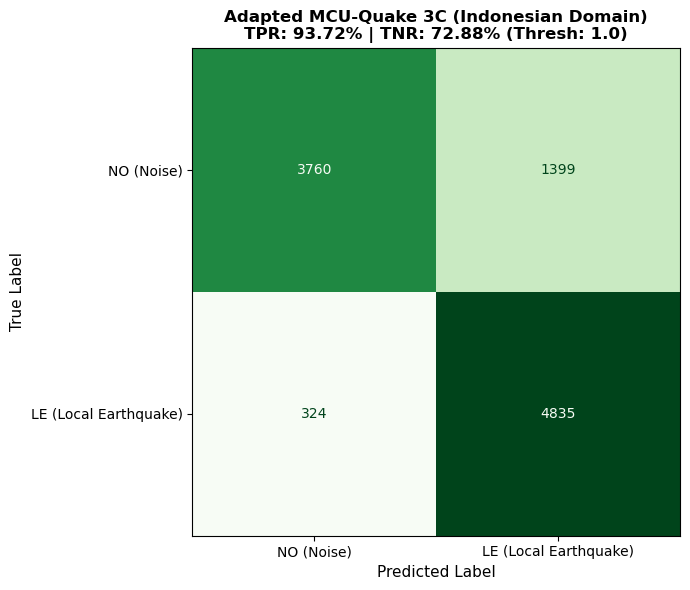

In [6]:
# -*- coding: utf-8 -*-
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from Library import utils, dataset
import logging

# ==============================================================================
# 1. KONFIGURASI PATH
# ==============================================================================
KEY_DATA_DIR = '/Volumes/Extreme SSD/json_indonesia_juli_sesi_5'
KEY_TEST_FILE = "extracted_data_3c_sesi_clean.json"

#KEY_DATA_DIR = "/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_10000"
#KEY_TEST_FILE = 'STEAD_10k_3C_20260726_173059.json'  # Dataset uji / latih 3C yang bersih

BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")

# Menggunakan EMBEDDING 3C BARU hasil Domain Adaptation lokal Indonesia
EMB_DIR = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/indonesia_domain_embeddings_3c_le'

# Direktori simpan hasil evaluasi akhir
SAVE_BASE = '/Volumes/Extreme SSD/unduhan_waveform_geofon/output/evaluation_adapted_3c_stead_results'
if not os.path.exists(SAVE_BASE):
    os.makedirs(SAVE_BASE)

INPUT_WIN = 7 
SAMPLING_RATE = 100
num_points = int(INPUT_WIN * SAMPLING_RATE)

# Ambang batas KDE (Gunakan 1.0 sebagai baseline pengujian awal)
KDE_THRESHOLD = 1.0 

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "="*60)
    print("🚀 EVALUASI AKHIR: MODEL 3C DENGAN EMBEDDING DOMAIN INDONESIA")
    print("="*60)

    # 1. Load Dataset 3C
    print("[INFO] Memuat Dataset Pengujian 3C JSON...")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    keys_list = list(test_data.keys())
    
    # 2. Load Model & Embedding Adaptasi 3C Lokal
    # 2. Load Model & Embedding Adaptasi 3C Lokal
    print("[INFO] Memuat Model CNN dan Embedding KDE 3D Lokal...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
    
    print("[INFO] Mengkalkulasi Distribusi PDF 3D KDE Berbasis Domain Lokal 3C...")
    # PERBAIKAN: Tambahkan parameter source_list=['noise', 'signal'] secara eksplisit
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E, source_list=['noise', 'le'])

    # 3. Ekstraksi Fitur Laten & Inferensi KDE 3C (Dengan Debugging Error)
    print(f"[INFO] Mengeksekusi inferensi 3C untuk {len(keys_list)} sampel...")
    total_true = []
    total_pred = []
    
    error_count = 0
    for i in tqdm(range(len(keys_list)), desc="Evaluasi Sampel 3C"):
        record_key = keys_list[i]
        record = test_data[record_key]
        
        try:
            # Ambil data 3 komponen
            raw_Zn = np.array(record["Z_noise"][-num_points:])
            raw_Zs = np.array(record["Z"][:num_points])
            
            raw_Nn = np.array(record["N_noise"][-num_points:])
            raw_Ns = np.array(record["N"][:num_points])
            
            raw_En = np.array(record["E_noise"][-num_points:])
            raw_Es = np.array(record["E"][:num_points])

            # Ekstraksi ruang laten 1D
            _in_Zn = utils.latent_codes_1D(raw_Zn, embedding_model)
            _in_Zs = utils.latent_codes_1D(raw_Zs, embedding_model)
            _in_Nn = utils.latent_codes_1D(raw_Nn, embedding_model)
            _in_Ns = utils.latent_codes_1D(raw_Ns, embedding_model)
            _in_En = utils.latent_codes_1D(raw_En, embedding_model)
            _in_Es = utils.latent_codes_1D(raw_Es, embedding_model)

            # Inferensi KDE 3C
            emb_n = np.array([_in_Zn, _in_Nn, _in_En]).reshape(1, -1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            emb_s = np.array([_in_Zs, _in_Ns, _in_Es]).reshape(1, -1) 
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            total_true.extend([0, 1])
            total_pred.extend([
                1 if p_n >= KDE_THRESHOLD else 0, 
                1 if p_s >= KDE_THRESHOLD else 0
            ])
            
        except Exception as e:
            error_count += 1
            if error_count <= 3:  # Cetak 3 error pertama untuk analisis
                print(f"\n[DEBUG ERROR pada key {record_key}]: {e}")
            continue

    print(f"\n[INFO] Total error/skipped during evaluation: {error_count} dari {len(keys_list)} sampel.")
    # 4. Kalkulasi Metrik Evaluasi Independen (Sklearn)
    cm = confusion_matrix(total_true, total_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    tpr = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0  # Sensitivitas / Recall Gempa
    tnr = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0  # Spesifisitas / Penolakan Derau
    ppv = (tp / (tp + fp)) * 100 if (tp + fp) > 0 else 0  # Precision Gempa
    accuracy = ((tp + tn) / (tp + tn + fp + fn)) * 100

    print("\n" + "="*50)
    print("📊 HASIL EVALUASI AKHIR MODEL 3C (DOMISILI INDONESIA)")
    print("="*50)
    print(f"🔹 True Negatives (Derau benar ditolak) : {tn}")
    print(f"🔸 False Positives (Derau salah gempa)  : {fp}")
    print(f"🔸 False Negatives (Gempa terlewat)     : {fn}")
    print(f"🔹 True Positives (Gempa terdeteksi)    : {tp}")
    print("-" * 50)
    print(f"✅ Sensitivitas (TPR)  : {tpr:.2f}%")
    print(f"✅ Spesifisitas (TNR)  : {tnr:.2f}%")
    print(f"✅ Presisi (PPV)       : {ppv:.2f}%")
    print(f"✅ Akurasi Total       : {accuracy:.2f}%")
    print("="*50)

    # 5. Plotting Confusion Matrix
    plt.figure(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NO (Noise)', 'LE (Local Earthquake)'])
    disp.plot(cmap=plt.cm.Greens, values_format='d', ax=plt.gca(), colorbar=False)
    
    plt.title(f'Adapted MCU-Quake 3C (Indonesian Domain)\nTPR: {tpr:.2f}% | TNR: {tnr:.2f}% (Thresh: {KDE_THRESHOLD})', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    
    save_path = os.path.join(SAVE_BASE, "confusion_matrix_adapted_3c.jpg")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"\n[INFO] Visualisasi Confusion Matrix 3C disimpan di: {save_path}")